## AND-103 Task 6: ML Pipeline

Predicts `outcome_class` from `data/feature_matrix.csv` using a time-based
train/test split and scikit-learn `Pipeline` objects.

**Goal:** beat the naive baseline (always predict the most common class).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

## AND-103 Task 6: Step 1 — Load Feature Matrix

In [2]:
fm = pd.read_csv('../data/feature_matrix.csv', parse_dates=['InspectionDate'])
print(f'Loaded {len(fm):,} rows × {fm.shape[1]} columns')
print(f'Date range: {fm["InspectionDate"].min().date()} → {fm["InspectionDate"].max().date()}')
print(f'\nTarget distribution:')
print(fm['outcome_class'].value_counts().to_string())

IDENTIFIER_COLS = ['ElevatingDevicesNumber', 'InspectionDate']
TARGET_COL = 'outcome_class'

Loaded 143,181 rows × 96 columns
Date range: 2011-01-04 → 2017-01-09

Target distribution:
outcome_class
Follow up              54605
Passed                 26064
DC Follow up           22302
All Orders Resolved    19555
Complete                7506
Shutdown                6110
Other                   2201
Follow up Major         1117
Follow up Sub Major     1002
Follow Up Initial        877
Unable to Inspect        689
Fail Initial             602
Passed Major             551


## AND-103 Task 6: Step 2 — Baseline Score

The **naive baseline** is the accuracy achieved by always predicting the most common
class, without any model. This is the floor the trained model must beat to provide value.

Two baseline figures are relevant:

| Baseline | Calculation | Value |
|---|---|---|
| Full-dataset naive | Follow up count / total rows | 38.1 % |
| Time-split test set | fraction of test rows = "Follow up" | 29.0 % |

The lower figure (29.0 %) is the operationally correct baseline: the test set covers
inspections from 2016 onward, where "Follow up" is less prevalent than in earlier years.
A model that only uses the training distribution to predict test outcomes must beat 29 %.

In [3]:
most_common_overall = fm[TARGET_COL].value_counts().index[0]
naive_baseline_full = fm[TARGET_COL].value_counts(normalize=True).iloc[0]
print(f'Most common class (full dataset): "{most_common_overall}"')
print(f'Naive baseline — full dataset:    {naive_baseline_full*100:.1f}%')

Most common class (full dataset): "Follow up"
Naive baseline — full dataset:    38.1%


## AND-103 Task 6: Step 3 — Time-Based Train / Test Split

A **random split** would allow the model to train on 2016 inspections and test on 2012
inspections — learning from the future to predict the past. This is temporal data leakage.

A **time-based split** preserves causal order: the model only ever trains on inspections
that occurred before the ones it is asked to predict. All inspections before the cutoff
date go to training; all on or after go to test.

In [4]:
fm_sorted = fm.sort_values('InspectionDate').reset_index(drop=True)

TRAIN_FRAC = 0.80
split_idx  = int(len(fm_sorted) * TRAIN_FRAC)
cutoff_date = fm_sorted.iloc[split_idx]['InspectionDate']

train_df = fm_sorted.iloc[:split_idx].copy()
test_df  = fm_sorted.iloc[split_idx:].copy()

print(f'Cutoff date: {cutoff_date.date()}')
print(f'Train: {len(train_df):,} rows  ({train_df["InspectionDate"].min().date()} – {train_df["InspectionDate"].max().date()})')
print(f'Test:  {len(test_df):,} rows  ({test_df["InspectionDate"].min().date()} – {test_df["InspectionDate"].max().date()})')

# Baseline on the actual test set
MOST_COMMON_TRAIN = train_df[TARGET_COL].value_counts().index[0]
BASELINE_TEST = (test_df[TARGET_COL] == MOST_COMMON_TRAIN).mean()
print(f'\nMost common class in training set: "{MOST_COMMON_TRAIN}" '
      f'({train_df[TARGET_COL].value_counts(normalize=True).iloc[0]*100:.1f}% of train)')
print(f'Baseline accuracy on test set:     {BASELINE_TEST*100:.1f}%')
print('(Always predict "Follow up" — the training set\'s most common class)')

Cutoff date: 2015-12-16
Train: 114,544 rows  (2011-01-04 – 2015-12-16)
Test:  28,637 rows  (2015-12-16 – 2017-01-09)

Most common class in training set: "Follow up" (40.4% of train)
Baseline accuracy on test set:     29.0%
(Always predict "Follow up" — the training set's most common class)


In [5]:
# Build feature matrices — drop identifiers and target
# Cast bool dummy columns to int so sklearn transformers accept them without warnings
def prep_X(df):
    X = df.drop(columns=IDENTIFIER_COLS + [TARGET_COL])
    bool_cols = X.select_dtypes(bool).columns
    return X.assign(**{c: X[c].astype(int) for c in bool_cols})

X_train = prep_X(train_df);  y_train = train_df[TARGET_COL]
X_test  = prep_X(test_df);   y_test  = test_df[TARGET_COL]

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'NaN in X_train: {X_train.isna().sum().sum():,}  (all from days_since_last_inspection — first inspections)')

X_train: (114544, 93)  |  X_test: (28637, 93)
NaN in X_train: 40,899  (all from days_since_last_inspection — first inspections)


## AND-103 Task 6: Step 4 — Model Pipelines

### Preprocessing steps

- **SimpleImputer (median):** fills `days_since_last_inspection` NaNs (43,324 rows whose
  first-ever inspection has no prior inspection date to measure from). Median imputation
  is used because the distribution is right-skewed (long gaps between initial inspections
  and subsequent ones).
- **StandardScaler:** applied only for LogisticRegression, which is sensitive to feature
  scale. RandomForest is scale-invariant.

### Feature selection

`SelectKBest(f_classif, k=30)` scores each feature using the ANOVA F-statistic between
the feature values and the target class labels, then keeps the 30 highest-scoring features.

`f_classif` is chosen over `mutual_info_classif` for two reasons:
1. It is deterministic (no random sampling), making results reproducible.
2. It is substantially faster on a 114 k-row dataset.

The trade-off: `f_classif` assumes a linear relationship between each feature and the
target; `mutual_info_classif` would capture non-linear associations at higher compute cost.
k = 30 (≈ 1/3 of 93 features) was chosen to reduce noise from the many sparse dummy
columns (city and outcome dummies with few non-zero values) while retaining the
continuous prior-history features that carry the most signal.

### Models

| Model | Rationale |
|---|---|
| `LogisticRegression` | Fast, interpretable linear baseline |
| `RandomForestClassifier` | Handles non-linearity and feature interactions without scaling |


In [6]:
K_BEST = 30

# LogisticRegression — all features
pipe_lr_full = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   LogisticRegression(max_iter=1000, random_state=42)),
])

# LogisticRegression — top K features
pipe_lr_sel = Pipeline([
    ('imputer',   SimpleImputer(strategy='median')),
    ('scaler',    StandardScaler()),
    ('selector',  SelectKBest(f_classif, k=K_BEST)),
    ('model',     LogisticRegression(max_iter=1000, random_state=42)),
])

# RandomForest — all features
pipe_rf_full = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   RandomForestClassifier(n_estimators=100, max_depth=20,
                                       random_state=42, n_jobs=-1)),
])

# RandomForest — top K features
pipe_rf_sel = Pipeline([
    ('imputer',  SimpleImputer(strategy='median')),
    ('selector', SelectKBest(f_classif, k=K_BEST)),
    ('model',    RandomForestClassifier(n_estimators=100, max_depth=20,
                                        random_state=42, n_jobs=-1)),
])

print('Pipelines defined.')

Pipelines defined.


## AND-103 Task 6: Step 5 — Train and Evaluate

In [7]:
configs = [
    ('Logistic Regression',  'all 93 features', pipe_lr_full),
    ('Logistic Regression',  f'top {K_BEST} features (SelectKBest)', pipe_lr_sel),
    ('Random Forest',        'all 93 features', pipe_rf_full),
    ('Random Forest',        f'top {K_BEST} features (SelectKBest)', pipe_rf_sel),
]

results = []
for model_name, feature_set, pipe in configs:
    print(f'Training {model_name} ({feature_set})...', end=' ', flush=True)
    pipe.fit(X_train, y_train)
    acc = accuracy_score(y_test, pipe.predict(X_test))
    results.append({
        'Model': model_name,
        'Features': feature_set,
        'Test accuracy': acc,
        'vs baseline': acc - BASELINE_TEST,
    })
    print(f'{acc*100:.1f}%')

results_df = pd.DataFrame(results)
print()
print('=== Results summary ===')
print(f'Baseline (always predict "{MOST_COMMON_TRAIN}"): {BASELINE_TEST*100:.1f}%')
print()
print(results_df.to_string(
    index=False,
    formatters={'Test accuracy': lambda x: f'{x*100:.1f}%',
                'vs baseline':   lambda x: f'{x*100:+.1f}pp'}
))

Training Logistic Regression (all 93 features)... 

32.0%
Training Logistic Regression (top 30 features (SelectKBest))... 

31.0%
Training Random Forest (all 93 features)... 

34.8%
Training Random Forest (top 30 features (SelectKBest))... 

33.7%

=== Results summary ===
Baseline (always predict "Follow up"): 29.0%

              Model                      Features Test accuracy vs baseline
Logistic Regression               all 93 features         32.0%      +3.0pp
Logistic Regression top 30 features (SelectKBest)         31.0%      +2.0pp
      Random Forest               all 93 features         34.8%      +5.8pp
      Random Forest top 30 features (SelectKBest)         33.7%      +4.7pp


## AND-103 Task 6: Step 6 — Feature Selection Analysis

In [8]:
# Inspect which features SelectKBest retained for the LR pipeline
selector = pipe_lr_sel.named_steps['selector']
feature_names = X_train.columns.tolist()
selected_mask = selector.get_support()
selected_features = [f for f, m in zip(feature_names, selected_mask) if m]
dropped_features  = [f for f, m in zip(feature_names, selected_mask) if not m]

print(f'Selected {len(selected_features)} features (k={K_BEST}):')
for f in selected_features:
    print(f'  {f}')
print(f'\nDropped {len(dropped_features)} features:')

Selected 30 features (k=30):
  prior_inspection_count
  days_since_last_inspection
  rolling_pass_rate
  prior_oc_all_orders_resolved
  prior_oc_complete
  prior_oc_dc_follow_up
  prior_oc_fail_initial
  prior_oc_follow_up
  prior_oc_follow_up_major
  prior_oc_follow_up_sub_major
  prior_oc_passed
  prior_oc_shutdown
  prior_it_ed_followup_inspection
  prior_it_ed_initial_inspection
  prior_it_ed_major_alteration_inspection
  prior_it_ed_minor_a_inspection
  prior_it_ed_periodic_inspection
  prior_it_ed_sub_inspection_major
  prior_order_count
  AlterationCount
  EquipmentType_nan
  Location_nan
  prior_outcome_All Orders Resolved
  prior_outcome_DC Follow up
  prior_outcome_Fail Initial
  prior_outcome_Follow up
  prior_outcome_Follow up Major
  prior_outcome_Follow up Sub Major
  prior_outcome_Passed
  prior_outcome_nan

Dropped 63 features:


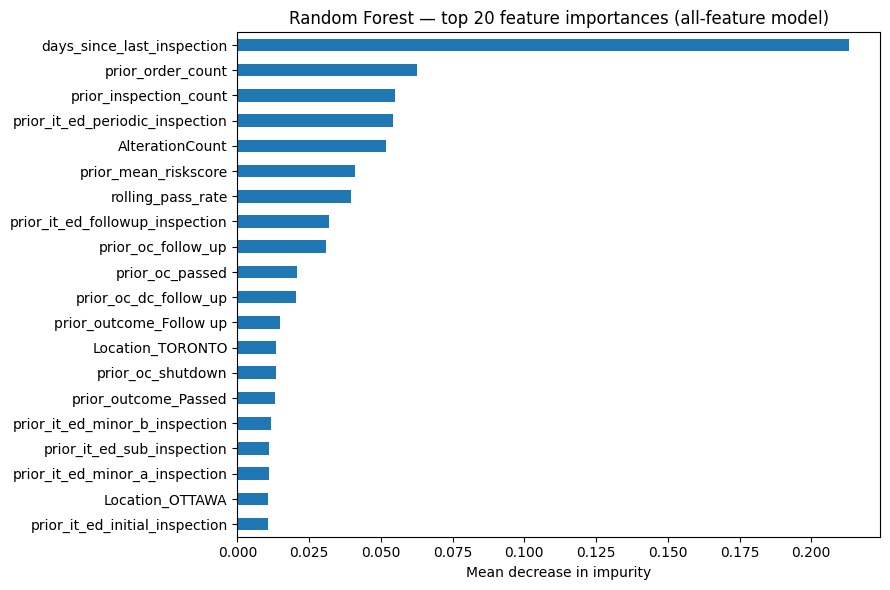

In [9]:
# Feature importance from RandomForest (all features)
rf_model = pipe_rf_full.named_steps['model']
importances = pd.Series(rf_model.feature_importances_, index=feature_names)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
top20.sort_values().plot.barh(ax=ax)
ax.set_title('Random Forest — top 20 feature importances (all-feature model)')
ax.set_xlabel('Mean decrease in impurity')
plt.tight_layout()
plt.show()

## AND-103 Task 6: Step 7 — Best Model and Classification Report

In [10]:
best_row = results_df.loc[results_df['Test accuracy'].idxmax()]
print(f'Best model: {best_row["Model"]} — {best_row["Features"]}')
print(f'Test accuracy:  {best_row["Test accuracy"]*100:.1f}%')
print(f'Baseline:       {BASELINE_TEST*100:.1f}%')
print(f'Improvement:    {best_row["vs baseline"]*100:+.1f} percentage points')
print()

# Select the best pipeline by name
best_pipe = dict(zip(
    [(r['Model'], r['Features']) for r in results],
    [p for _, _, p in configs]
))[(best_row['Model'], best_row['Features'])]

y_pred_best = best_pipe.predict(X_test)
print(classification_report(y_test, y_pred_best, zero_division=0))

Best model: Random Forest — all 93 features
Test accuracy:  34.8%
Baseline:       29.0%
Improvement:    +5.8 percentage points



                     precision    recall  f1-score   support

All Orders Resolved       0.41      0.49      0.44      7829
           Complete       0.35      0.08      0.13      2216
       DC Follow up       0.42      0.12      0.19      6955
       Fail Initial       1.00      0.01      0.02       186
  Follow Up Initial       0.13      0.01      0.01       270
          Follow up       0.32      0.57      0.41      8298
    Follow up Major       0.29      0.01      0.02       355
Follow up Sub Major       0.41      0.21      0.28       395
              Other       0.77      0.35      0.48       550
             Passed       0.03      0.26      0.06       125
       Passed Major       0.00      0.00      0.00       213
           Shutdown       0.20      0.01      0.02      1025
  Unable to Inspect       0.00      0.00      0.00       220

           accuracy                           0.35     28637
          macro avg       0.33      0.16      0.16     28637
       weighted avg   